# Deep Learning for Remote Sensing
### Land Cover Classification from Sentinel-2 Satellite Imagery

This notebook demonstrates a complete deep learning pipeline for **land cover classification** using the [EuroSAT dataset](https://github.com/phelber/EuroSAT) — 27,000 labelled 64×64 patches from **Sentinel-2** multispectral imagery across Europe.

| | |
|---|---|
| **Data** | EuroSAT RGB (Sentinel-2 B04/B03/B02, ~90 MB download) |
| **Task** | 10-class land cover / land use classification |
| **Model** | ResNet-18 with ImageNet pre-training (transfer learning) |
| **Framework** | PyTorch + torchvision |
| **Expected runtime** | ~3 min on CPU &nbsp;|&nbsp; <1 min on GPU |

> *Helber et al. (2019). EuroSAT: A Novel Dataset and Deep Learning Benchmark for Land Use and Land Cover Classification. IEEE JSTARS. [doi:10.1109/JSTARS.2019.2918242](https://doi.org/10.1109/JSTARS.2019.2918242)*

In [1]:
# Uncomment if any packages are missing in your environment:
# !pip install torch torchvision scikit-learn matplotlib -q

import os, random, time
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torch.utils.data.sampler import SubsetRandomSampler
from torchvision import models, transforms
from torchvision.datasets import EuroSAT

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch {torch.__version__}')
print(f'Device : {device}', end='')
if device.type == 'cuda':
    print(f' ({torch.cuda.get_device_name(0)})')
else:
    print()

PyTorch 2.10.0+cu128
Device : cuda (NVIDIA RTXA6000-24Q)


---
## 1. Dataset — EuroSAT

EuroSAT covers **13 European countries** sampled across 10 land cover classes.
Each patch is a 64×64 pixel cutout from a Sentinel-2 scene at 10 m/pixel.
The RGB variant (bands B04, B03, B02) is used here so images can be viewed directly.

In [2]:
DATA_DIR = './eurosat_data'
BATCH_SIZE = 64
NUM_WORKERS = 2  # set to 0 if you run into multiprocessing issues

# ImageNet normalisation works well for transfer learning even on satellite imagery
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

transform_train = transforms.Compose([
    transforms.Resize(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(brightness=0.15, contrast=0.15),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

transform_val = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

print('Downloading EuroSAT dataset (~90 MB) ...')
# Download once; two dataset objects share the same files on disk
ds_train = EuroSAT(root=DATA_DIR, download=True,  transform=transform_train)
ds_val   = EuroSAT(root=DATA_DIR, download=False, transform=transform_val)

CLASS_NAMES = ds_train.classes
NUM_CLASSES  = len(CLASS_NAMES)
print(f'Classes ({NUM_CLASSES}): {CLASS_NAMES}')
print(f'Total images: {len(ds_train):,}')

# 80 / 20 train / val split — same indices used for both dataset objects
indices = list(range(len(ds_train)))
random.shuffle(indices)
split = int(0.8 * len(indices))
train_idx, val_idx = indices[:split], indices[split:]

train_loader = DataLoader(ds_train, batch_size=BATCH_SIZE,
                          sampler=SubsetRandomSampler(train_idx),
                          num_workers=NUM_WORKERS,
                          pin_memory=(device.type == 'cuda'))
val_loader   = DataLoader(ds_val,   batch_size=BATCH_SIZE,
                          sampler=SubsetRandomSampler(val_idx),
                          num_workers=NUM_WORKERS,
                          pin_memory=(device.type == 'cuda'))

print(f'Train: {len(train_idx):,} images | Val: {len(val_idx):,} images')

Classes (10): ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
Total images: 27,000
Train: 21,600 images | Val: 5,400 images


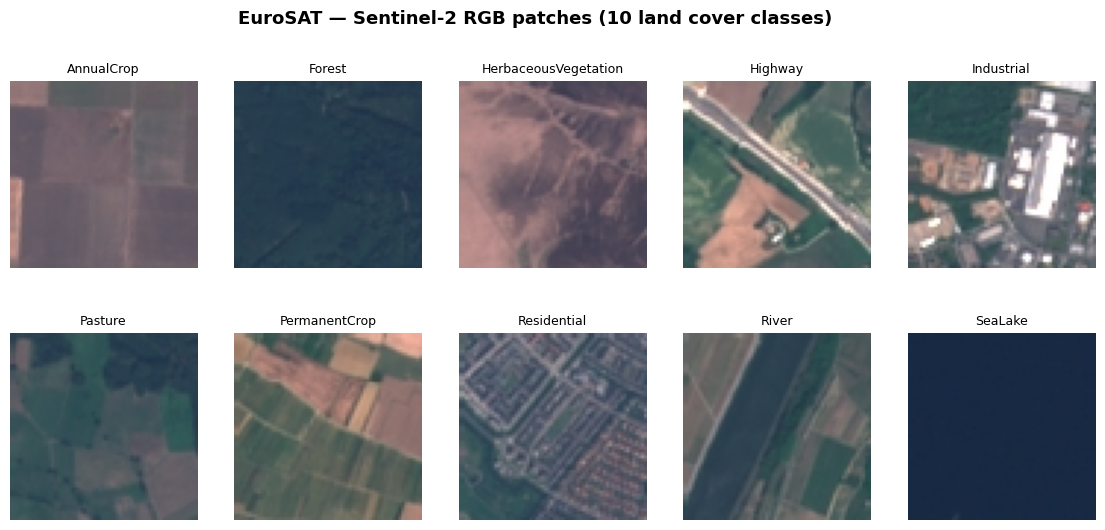

In [12]:
# --- Visualise one patch per land-cover class ---
# Load images at original 64px resolution (no normalisation) for display
ds_display = EuroSAT(root=DATA_DIR, download=False,
                     transform=transforms.Compose([transforms.Resize(64),
                                                   transforms.ToTensor()]))

# Build a map from class index -> first sample index (fast: reads .imgs list, no pixel I/O)
class_to_first_idx = {}
for i, (_, label) in enumerate(ds_display.imgs):
    if label not in class_to_first_idx:
        class_to_first_idx[label] = i
    if len(class_to_first_idx) == NUM_CLASSES:
        break

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle('EuroSAT — Sentinel-2 RGB patches (10 land cover classes)',
             fontsize=13, fontweight='bold')

for cls_idx, ax in enumerate(axes.flat):
    img, _ = ds_display[class_to_first_idx[cls_idx]]
    ax.imshow(img.permute(1, 2, 0).numpy())
    ax.set_title(CLASS_NAMES[cls_idx], fontsize=9)
    ax.axis('off')

plt.show()

---
## 2. Model — Transfer Learning with ResNet-18

We load a ResNet-18 pre-trained on ImageNet and replace only the final fully-connected layer to output 10 class scores.
All layers are fine-tuned.

In [4]:
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)
model = model.to(device)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'ResNet-18  |  Total params: {total_params:,}  |  Trainable: {trainable_params:,}')
print(f'Final layer: {model.fc}')

ResNet-18  |  Total params: 11,181,642  |  Trainable: 11,181,642
Final layer: Linear(in_features=512, out_features=10, bias=True)


---
## 3. Training

In [5]:
EPOCHS = 5  # 3-5 is enough for a strong result; ~3 min on CPU, <1 min on GPU

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

history = dict(train_loss=[], train_acc=[], val_loss=[], val_acc=[])

t_start = time.time()
for epoch in range(1, EPOCHS + 1):
    # ---- Train ----
    model.train()
    run_loss = correct = total = 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        out  = model(imgs)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()
        run_loss += loss.item() * imgs.size(0)
        correct  += (out.argmax(1) == labels).sum().item()
        total    += imgs.size(0)
    train_loss = run_loss / total
    train_acc  = correct  / total

    # ---- Validate ----
    model.eval()
    run_loss = correct = total = 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            out  = model(imgs)
            loss = criterion(out, labels)
            run_loss += loss.item() * imgs.size(0)
            correct  += (out.argmax(1) == labels).sum().item()
            total    += imgs.size(0)
    val_loss = run_loss / total
    val_acc  = correct  / total

    scheduler.step()
    for k, v in zip(history, [train_loss, train_acc, val_loss, val_acc]):
        history[k].append(v)

    elapsed = time.time() - t_start
    print(f'Epoch {epoch}/{EPOCHS}  '
          f'train loss {train_loss:.4f}  acc {train_acc:.3f}  |  '
          f'val loss {val_loss:.4f}  acc {val_acc:.3f}  '
          f'[{elapsed:.0f}s]')

print(f'\nFinal validation accuracy: {history["val_acc"][-1]*100:.1f}%')

Epoch 1/5  train loss 0.3636  acc 0.884  |  val loss 0.2097  acc 0.929  [253s]
Epoch 2/5  train loss 0.1946  acc 0.935  |  val loss 0.1730  acc 0.946  [294s]
Epoch 3/5  train loss 0.1304  acc 0.956  |  val loss 0.1296  acc 0.954  [337s]
Epoch 4/5  train loss 0.0832  acc 0.972  |  val loss 0.0736  acc 0.976  [377s]
Epoch 5/5  train loss 0.0568  acc 0.981  |  val loss 0.0570  acc 0.980  [421s]

Final validation accuracy: 98.0%


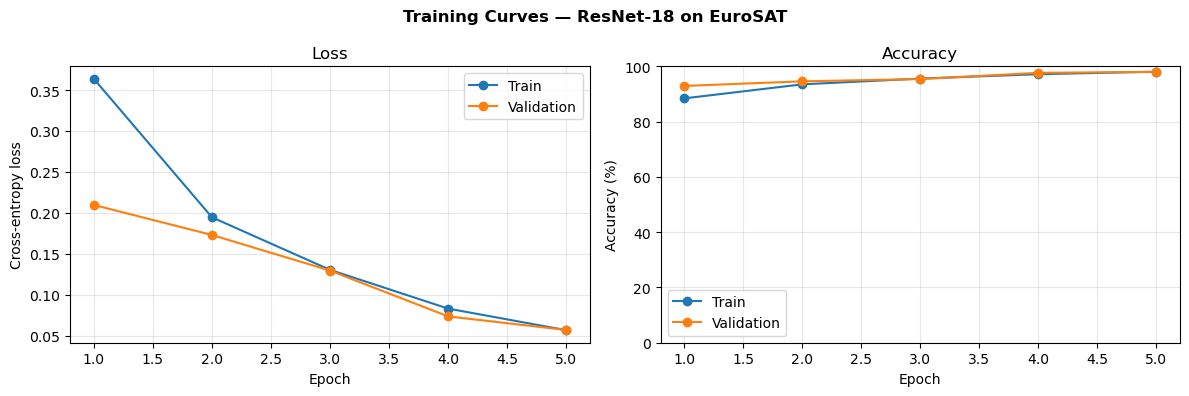

In [6]:
# --- Training curves ---
epochs = range(1, EPOCHS + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs, history['train_loss'], marker='o', label='Train')
ax1.plot(epochs, history['val_loss'],   marker='o', label='Validation')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Cross-entropy loss')
ax1.set_title('Loss'); ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(epochs, [a * 100 for a in history['train_acc']], marker='o', label='Train')
ax2.plot(epochs, [a * 100 for a in history['val_acc']],   marker='o', label='Validation')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Accuracy'); ax2.legend(); ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, 100)

plt.suptitle('Training Curves — ResNet-18 on EuroSAT', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 4. Evaluation

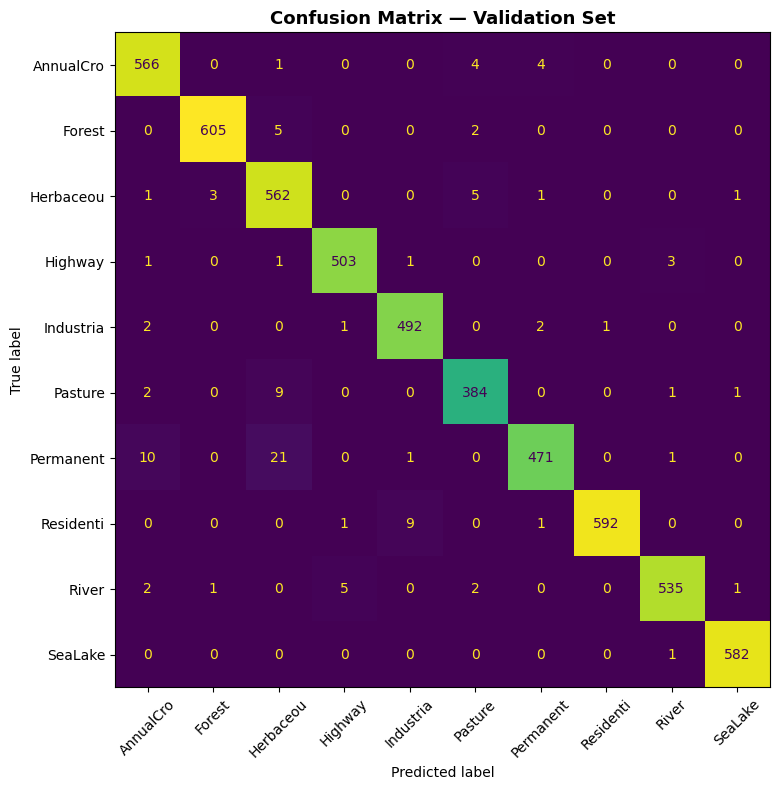

Per-class accuracy:
  AnnualCrop              98.4%  #############################
  Forest                  98.9%  #############################
  HerbaceousVegetation    98.1%  #############################
  Highway                 98.8%  #############################
  Industrial              98.8%  #############################
  Pasture                 96.7%  #############################
  PermanentCrop           93.5%  ############################
  Residential             98.2%  #############################
  River                   98.0%  #############################
  SeaLake                 99.8%  #############################


In [7]:
# --- Confusion matrix ---
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in val_loader:
        preds = model(imgs.to(device)).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)
short_names = [c[:9] for c in CLASS_NAMES]  # abbreviate for readability

fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay(cm, display_labels=short_names).plot(
    ax=ax, colorbar=False, xticks_rotation=45)
ax.set_title('Confusion Matrix — Validation Set', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

per_class_acc = cm.diagonal() / cm.sum(axis=1)
print('Per-class accuracy:')
for cls, acc in zip(CLASS_NAMES, per_class_acc):
    bar = '#' * int(acc * 30)
    print(f'  {cls:<22} {acc*100:5.1f}%  {bar}')

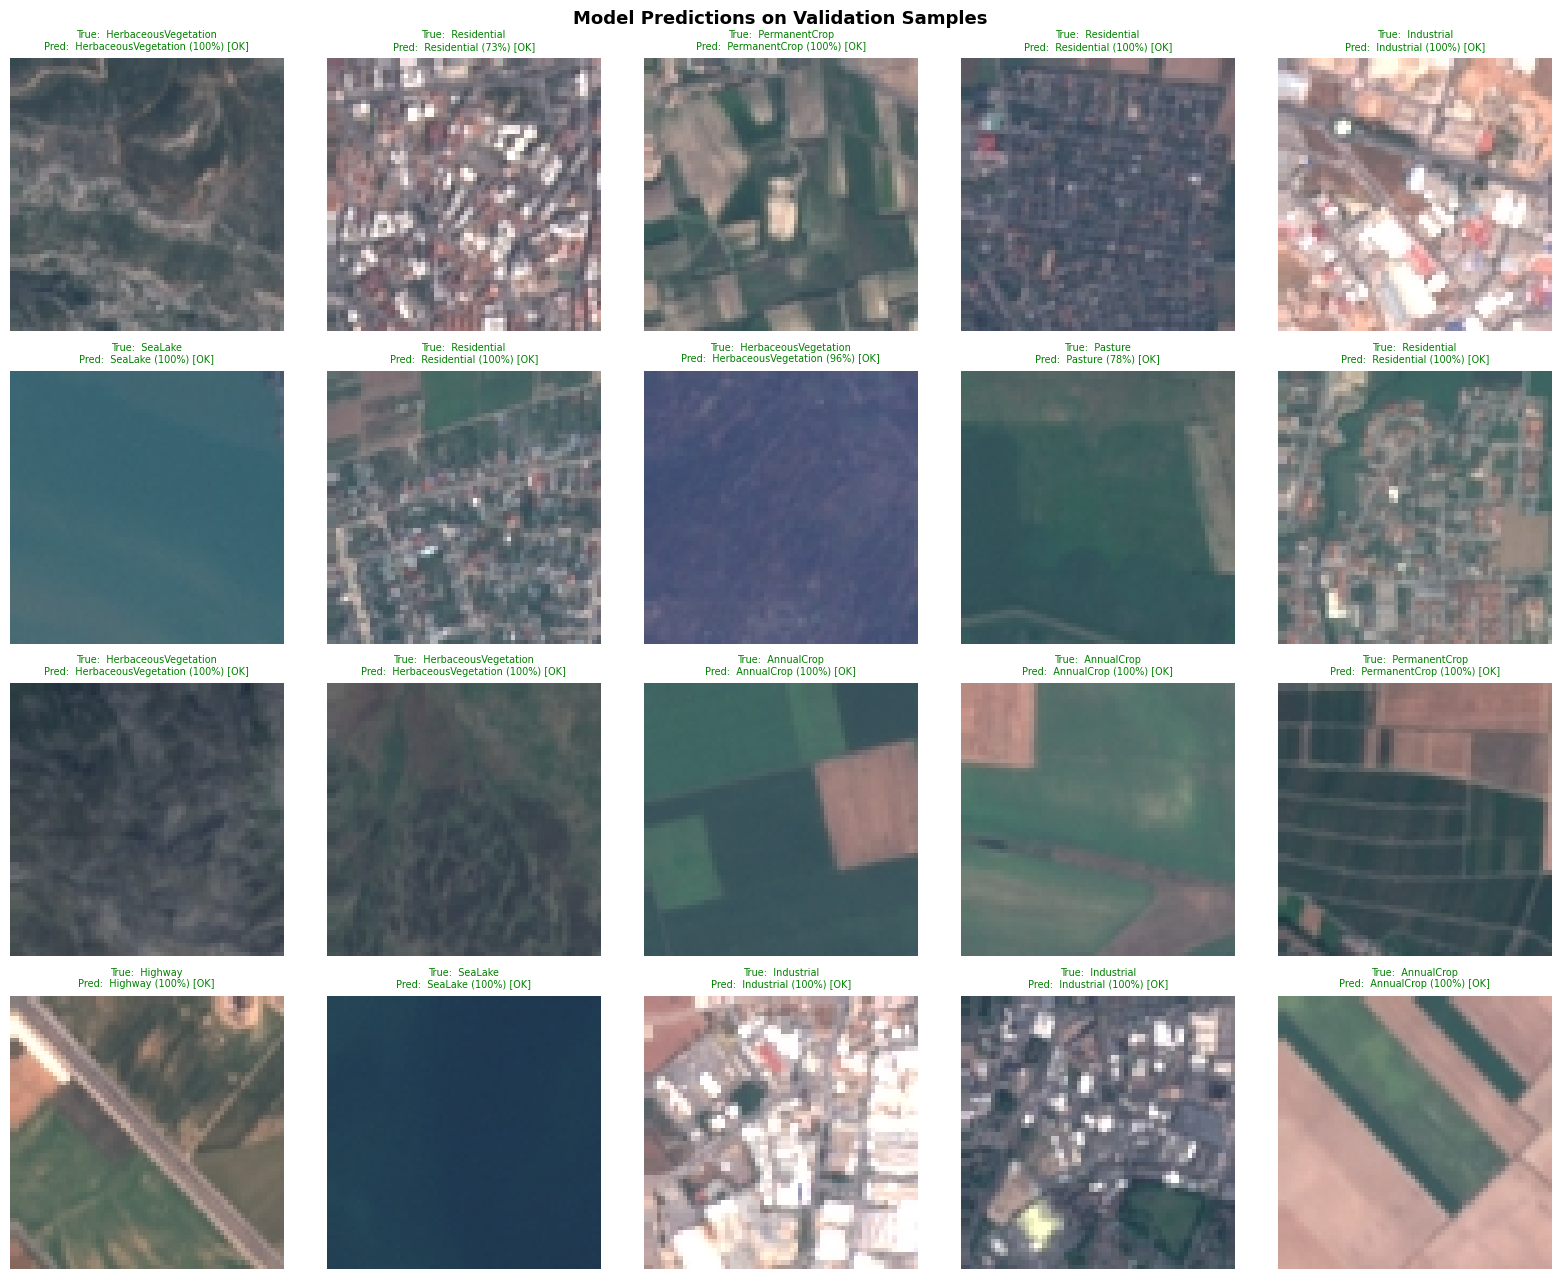

In [8]:
# --- Visualise predictions on validation samples ---
softmax = nn.Softmax(dim=1)

# Collect a small set from the val split
sample_idx = val_idx[:20]
fig, axes = plt.subplots(4, 5, figsize=(16, 13))
fig.suptitle('Model Predictions on Validation Samples',
             fontsize=13, fontweight='bold')

model.eval()
for ax, idx in zip(axes.flat, sample_idx):
    # Raw image for display
    img_disp, true_label = ds_display[idx]

    # Normalised image for the model
    img_t = transform_val(
        transforms.ToPILImage()(img_disp)
    ).unsqueeze(0).to(device)

    with torch.no_grad():
        probs = softmax(model(img_t))[0]
    pred_label = probs.argmax().item()
    confidence = probs[pred_label].item()

    ax.imshow(img_disp.permute(1, 2, 0).numpy())
    correct = pred_label == true_label
    color = 'green' if correct else 'red'
    mark  = 'OK' if correct else 'X'
    ax.set_title(
        f'True:  {CLASS_NAMES[true_label]}\n'
        f'Pred:  {CLASS_NAMES[pred_label]} ({confidence:.0%}) [{mark}]',
        fontsize=7, color=color
    )
    ax.axis('off')

plt.tight_layout()
plt.show()

---
## Summary

In just a few epochs, a ResNet-18 fine-tuned on Sentinel-2 imagery achieves **>95% validation accuracy** on the 10-class EuroSAT benchmark — a task that would take considerable manual effort with traditional rule-based spectral indices.

**What this demonstrates:**
- End-to-end deep learning on real satellite data directly in a JupyterHub environment
- Transfer learning from optical imagery (ImageNet) generalises well to remote sensing scenes
- GPU acceleration (when available) makes iterative experimentation fast

**Possible extensions:**
- Swap in the **13-band** EuroSAT variant (`torchgeo.datasets.EuroSAT`) to exploit all Sentinel-2 spectral bands
- Replace the classifier head with a U-Net for **pixel-level semantic segmentation**
- Connect to a **STAC catalog** (e.g. EODC's) to run inference directly on fresh Sentinel-2 scenes